In [2]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np

dataset = pd.read_csv("/content/day.csv")

dataset

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2018,1,0,1,0,1,1,2,14.110847,18.18125,80.5833,10.749882,331,654,985
1,2,02-01-2018,1,0,1,0,2,1,2,14.902598,17.68695,69.6087,16.652113,131,670,801
2,3,03-01-2018,1,0,1,0,3,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,4,04-01-2018,1,0,1,0,4,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,5,05-01-2018,1,0,1,0,5,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
725,726,27-12-2019,1,1,12,0,5,1,2,10.420847,11.33210,65.2917,23.458911,247,1867,2114
726,727,28-12-2019,1,1,12,0,6,0,2,10.386653,12.75230,59.0000,10.416557,644,2451,3095
727,728,29-12-2019,1,1,12,0,0,0,2,10.386653,12.12000,75.2917,8.333661,159,1182,1341
728,729,30-12-2019,1,1,12,0,1,1,1,10.489153,11.58500,48.3333,23.500518,364,1432,1796


In [3]:
dataset.shape

(730, 16)

In [4]:
dataset.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')

In [5]:
dataset.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000
mean,365.500000,2.498630,0.500000,6.526027,0.028767,2.995890,0.690411,1.394521,20.319259,23.726322,62.765175,12.763620,849.249315,3658.757534,4508.006849
std,210.877136,1.110184,0.500343,3.450215,0.167266,2.000339,0.462641,0.544807,7.506729,8.150308,14.237589,5.195841,686.479875,1559.758728,1936.011647
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.424346,3.953480,0.000000,1.500244,2.000000,20.000000,22.000000
25%,183.250000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,13.811885,16.889713,52.000000,9.041650,316.250000,2502.250000,3169.750000
50%,365.500000,3.000000,0.500000,7.000000,0.000000,3.000000,1.000000,1.000000,20.465826,24.368225,62.625000,12.125325,717.000000,3664.500000,4548.500000
75%,547.750000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,26.880615,30.445775,72.989575,15.625589,1096.500000,4783.250000,5966.000000
max,730.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,35.328347,42.044800,97.250000,34.000021,3410.000000,6946.000000,8714.000000


In [6]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     730 non-null    int64  
 1   dteday      730 non-null    object 
 2   season      730 non-null    int64  
 3   yr          730 non-null    int64  
 4   mnth        730 non-null    int64  
 5   holiday     730 non-null    int64  
 6   weekday     730 non-null    int64  
 7   workingday  730 non-null    int64  
 8   weathersit  730 non-null    int64  
 9   temp        730 non-null    float64
 10  atemp       730 non-null    float64
 11  hum         730 non-null    float64
 12  windspeed   730 non-null    float64
 13  casual      730 non-null    int64  
 14  registered  730 non-null    int64  
 15  cnt         730 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.4+ KB


In [ ]:
dataset.loc[(dataset['season'] == 1), 'season'] = 'spring'
dataset.loc[(dataset['season'] == 2), 'season'] = 'summer'
dataset.loc[(dataset['season'] == 3), 'season'] = 'fall'
dataset.loc[(dataset['season'] == 4), 'season'] = 'winter'

In [9]:
dataset['season'].astype('category').value_counts()

,count
season,
3,188
2,184
1,180
4,178


In [10]:
dataset['yr'].astype('category').value_counts()

,count
yr,
0,365
1,365


In [ ]:
def object_map_mnths(x):
  return x.map({1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun', 7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'})

In [ ]:
dataset[['mnth']] = dataset[['mnth']].apply(object_map_mnths)

In [11]:
dataset['mnth'].astype('category').value_counts()

,count
mnth,
1,62
3,62
7,62
5,62
12,62
10,62
8,62
4,60
9,60


In [12]:
dataset['holiday'].astype('category').value_counts()

,count
holiday,
0,709
1,21


In [ ]:
def str_map_weekday(x):
  return x.map({1: 'Mon', 2: 'Tues', 3: 'Wed', 4: 'Thurs', 5: 'Fri', 6: 'Sat', 0: 'Sun'})

In [ ]:
dataset[['weekday']] = dataset[['weekday']].apply(str_map_weekday)


In [13]:
dataset['weekday'].astype('category').value_counts()

,count
weekday,
1,105
2,105
0,104
3,104
4,104
5,104
6,104


In [14]:
dataset['workingday'].astype('category').value_counts()

,count
workingday,
1,504
0,226


In [ ]:
dataset.loc[(dataset['weathersit']  == 1), 'weathersit'] = 'A'
dataset.loc[(dataset['weathersit']  == 2), 'weathersit'] = 'B'
dataset.loc[(dataset['weathersit']  == 3), 'weathersit'] = 'C'


In [15]:
dataset['weathersit'].astype('category').value_counts()

,count
weathersit,
1,463
2,246
3,21


             2. Data Visualisation

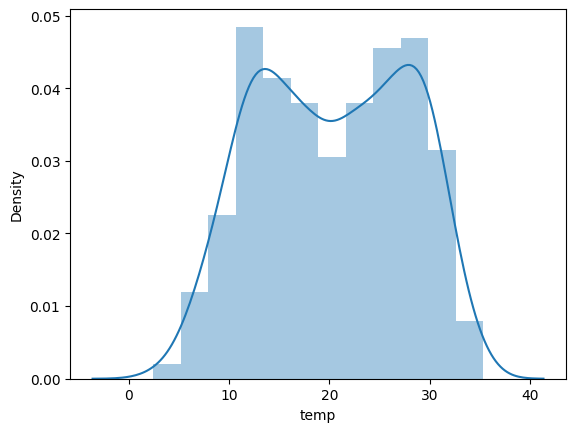

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.distplot(dataset['temp'])
plt.show()


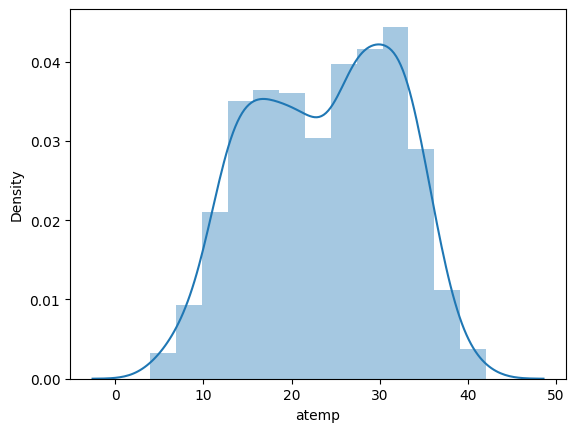

In [19]:
sns.distplot(dataset['atemp'])
plt.show()

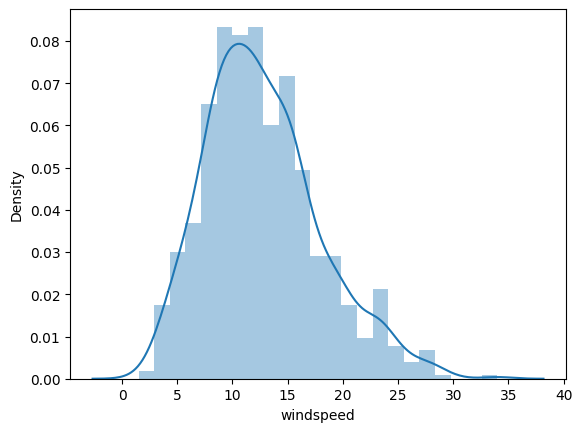

In [20]:
sns.distplot(dataset['windspeed'])
plt.show()

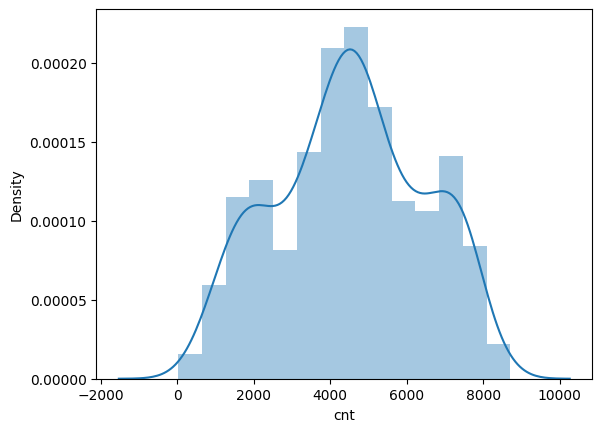

In [21]:
sns.distplot(dataset['cnt'])
plt.show()

In [ ]:
dataset['dteday'] = dataset['dteday'].astype('datetime64')

In [24]:
dataset_categorical = dataset.select_dtypes(exclude=['float64', 'datetime64', 'int64'])
dataset_categorical.columns

Index(['dteday'], dtype='object')

In [25]:
dataset_categorical

,dteday
0,01-01-2018
1,02-01-2018
2,03-01-2018
3,04-01-2018
4,05-01-2018
...,...
725,27-12-2019
726,28-12-2019
727,29-12-2019
728,30-12-2019


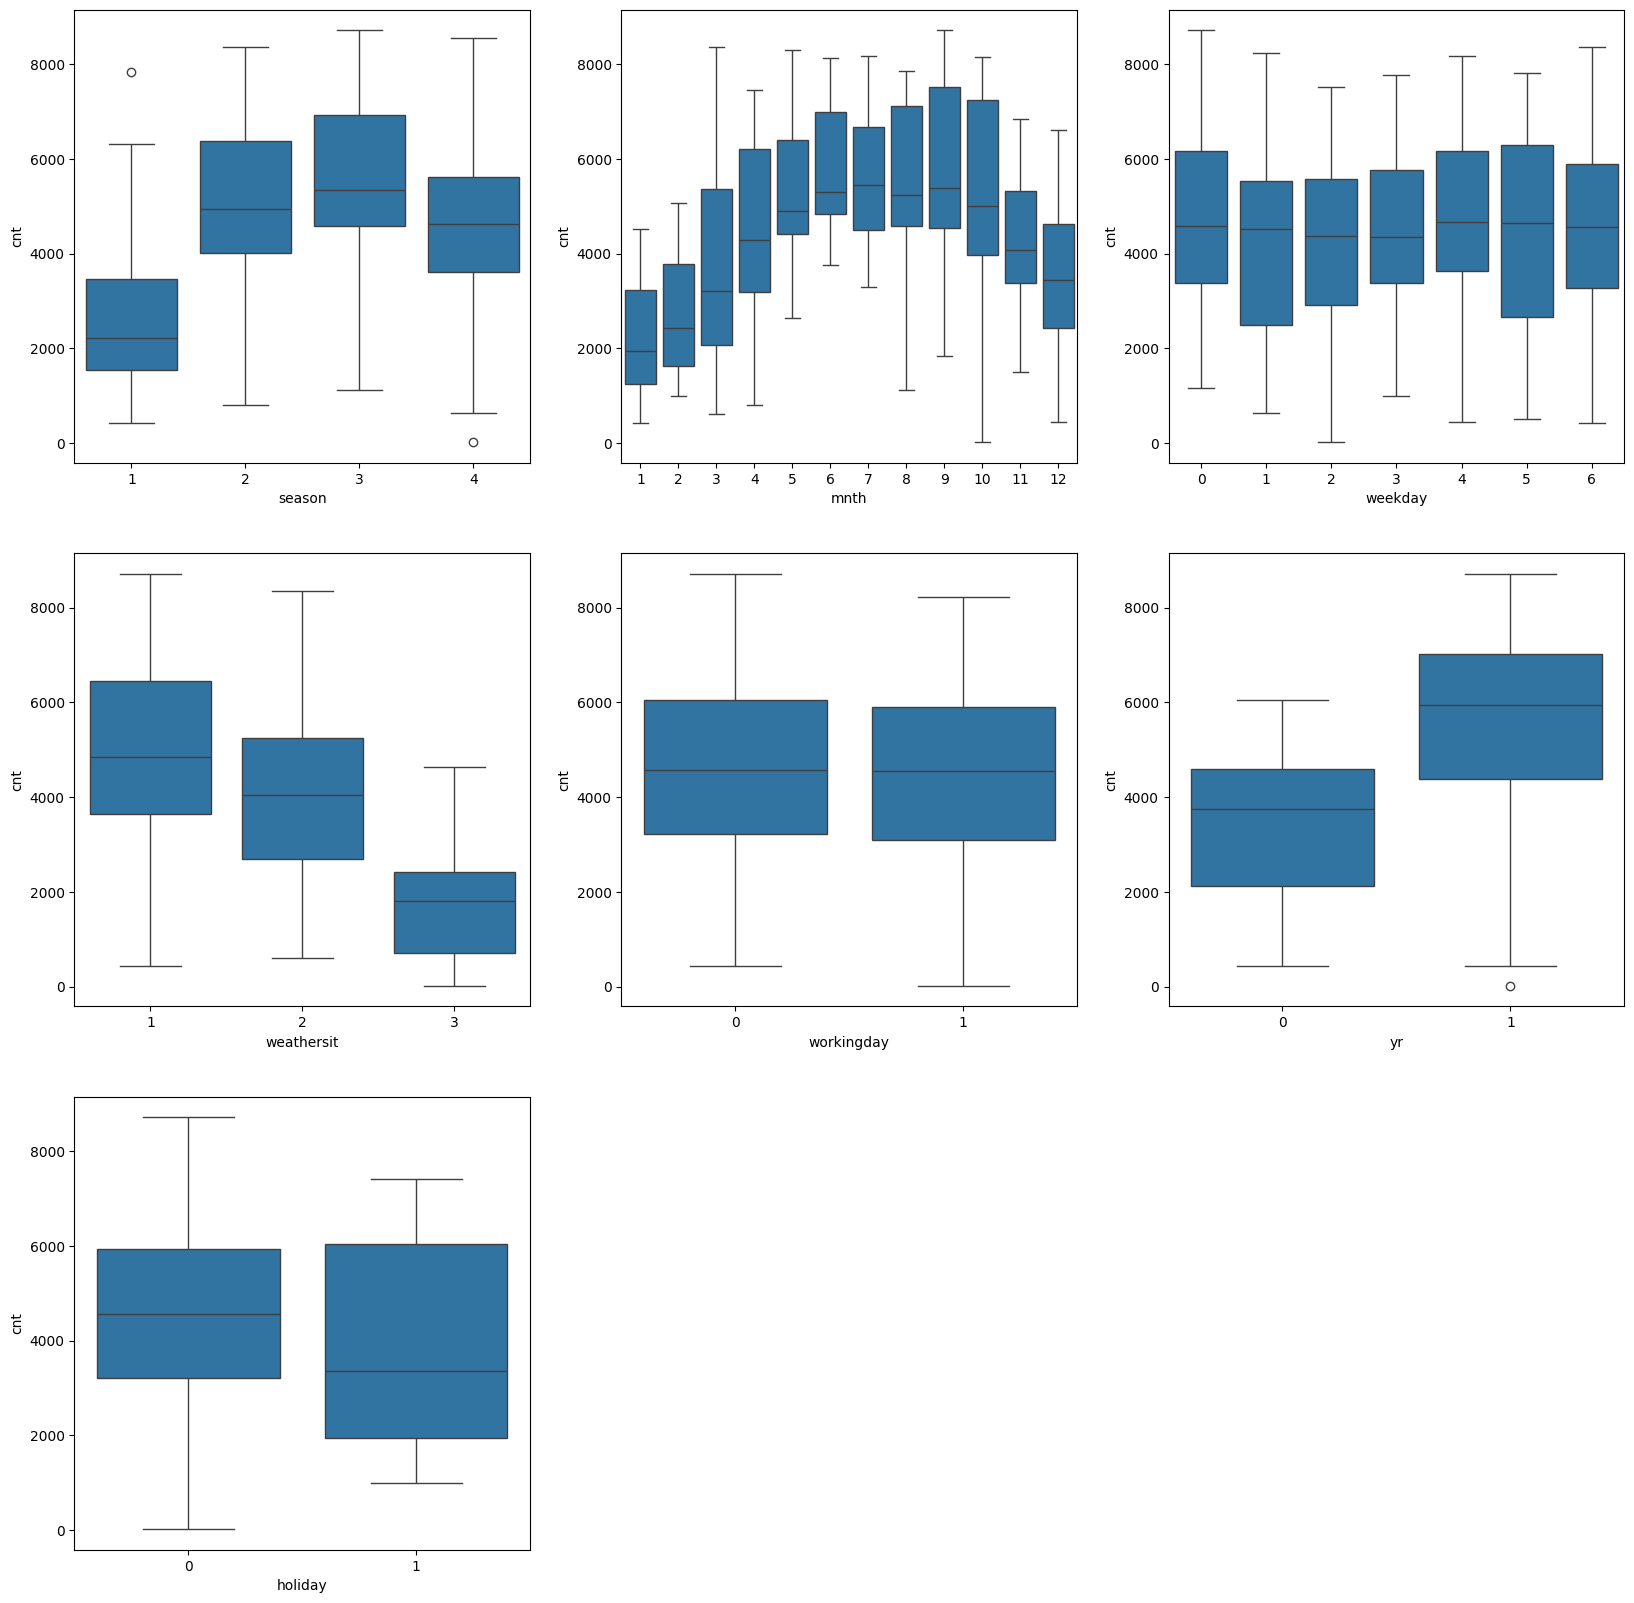

In [26]:
plt.figure(figsize=(20,20))
plt.subplot(3,3,1)
sns.boxplot(x = 'season', y = 'cnt', data = dataset)
plt.subplot(3,3,2)
sns.boxplot(x = 'mnth', y = 'cnt', data = dataset)
plt.subplot(3,3,3)
sns.boxplot(x = 'weekday', y = 'cnt', data = dataset)
plt.subplot(3,3,4)
sns.boxplot(x = 'weathersit', y = 'cnt', data = dataset)
plt.subplot(3,3,5)
sns.boxplot(x = 'workingday', y = 'cnt', data = dataset)
plt.subplot(3,3,6)
sns.boxplot(x = 'yr', y = 'cnt', data = dataset)
plt.subplot(3,3,7)
sns.boxplot(x = 'holiday', y = 'cnt', data = dataset)
plt.show()

In [30]:
intVarlist = ["casual", "registered", "cnt"]
for var in intVarlist:
  dataset[var] = dataset[var].astype("float")

dataset_numeric = dataset.select_dtypes(include=['float64'])
dataset_numeric.head()

,temp,atemp,hum,windspeed,casual,registered,cnt
0,14.110847,18.18125,80.5833,10.749882,331.0,654.0,985.0
1,14.902598,17.68695,69.6087,16.652113,131.0,670.0,801.0
2,8.050924,9.47025,43.7273,16.636703,120.0,1229.0,1349.0
3,8.200000,10.60610,59.0435,10.739832,108.0,1454.0,1562.0
4,9.305237,11.46350,43.6957,12.522300,82.0,1518.0,1600.0


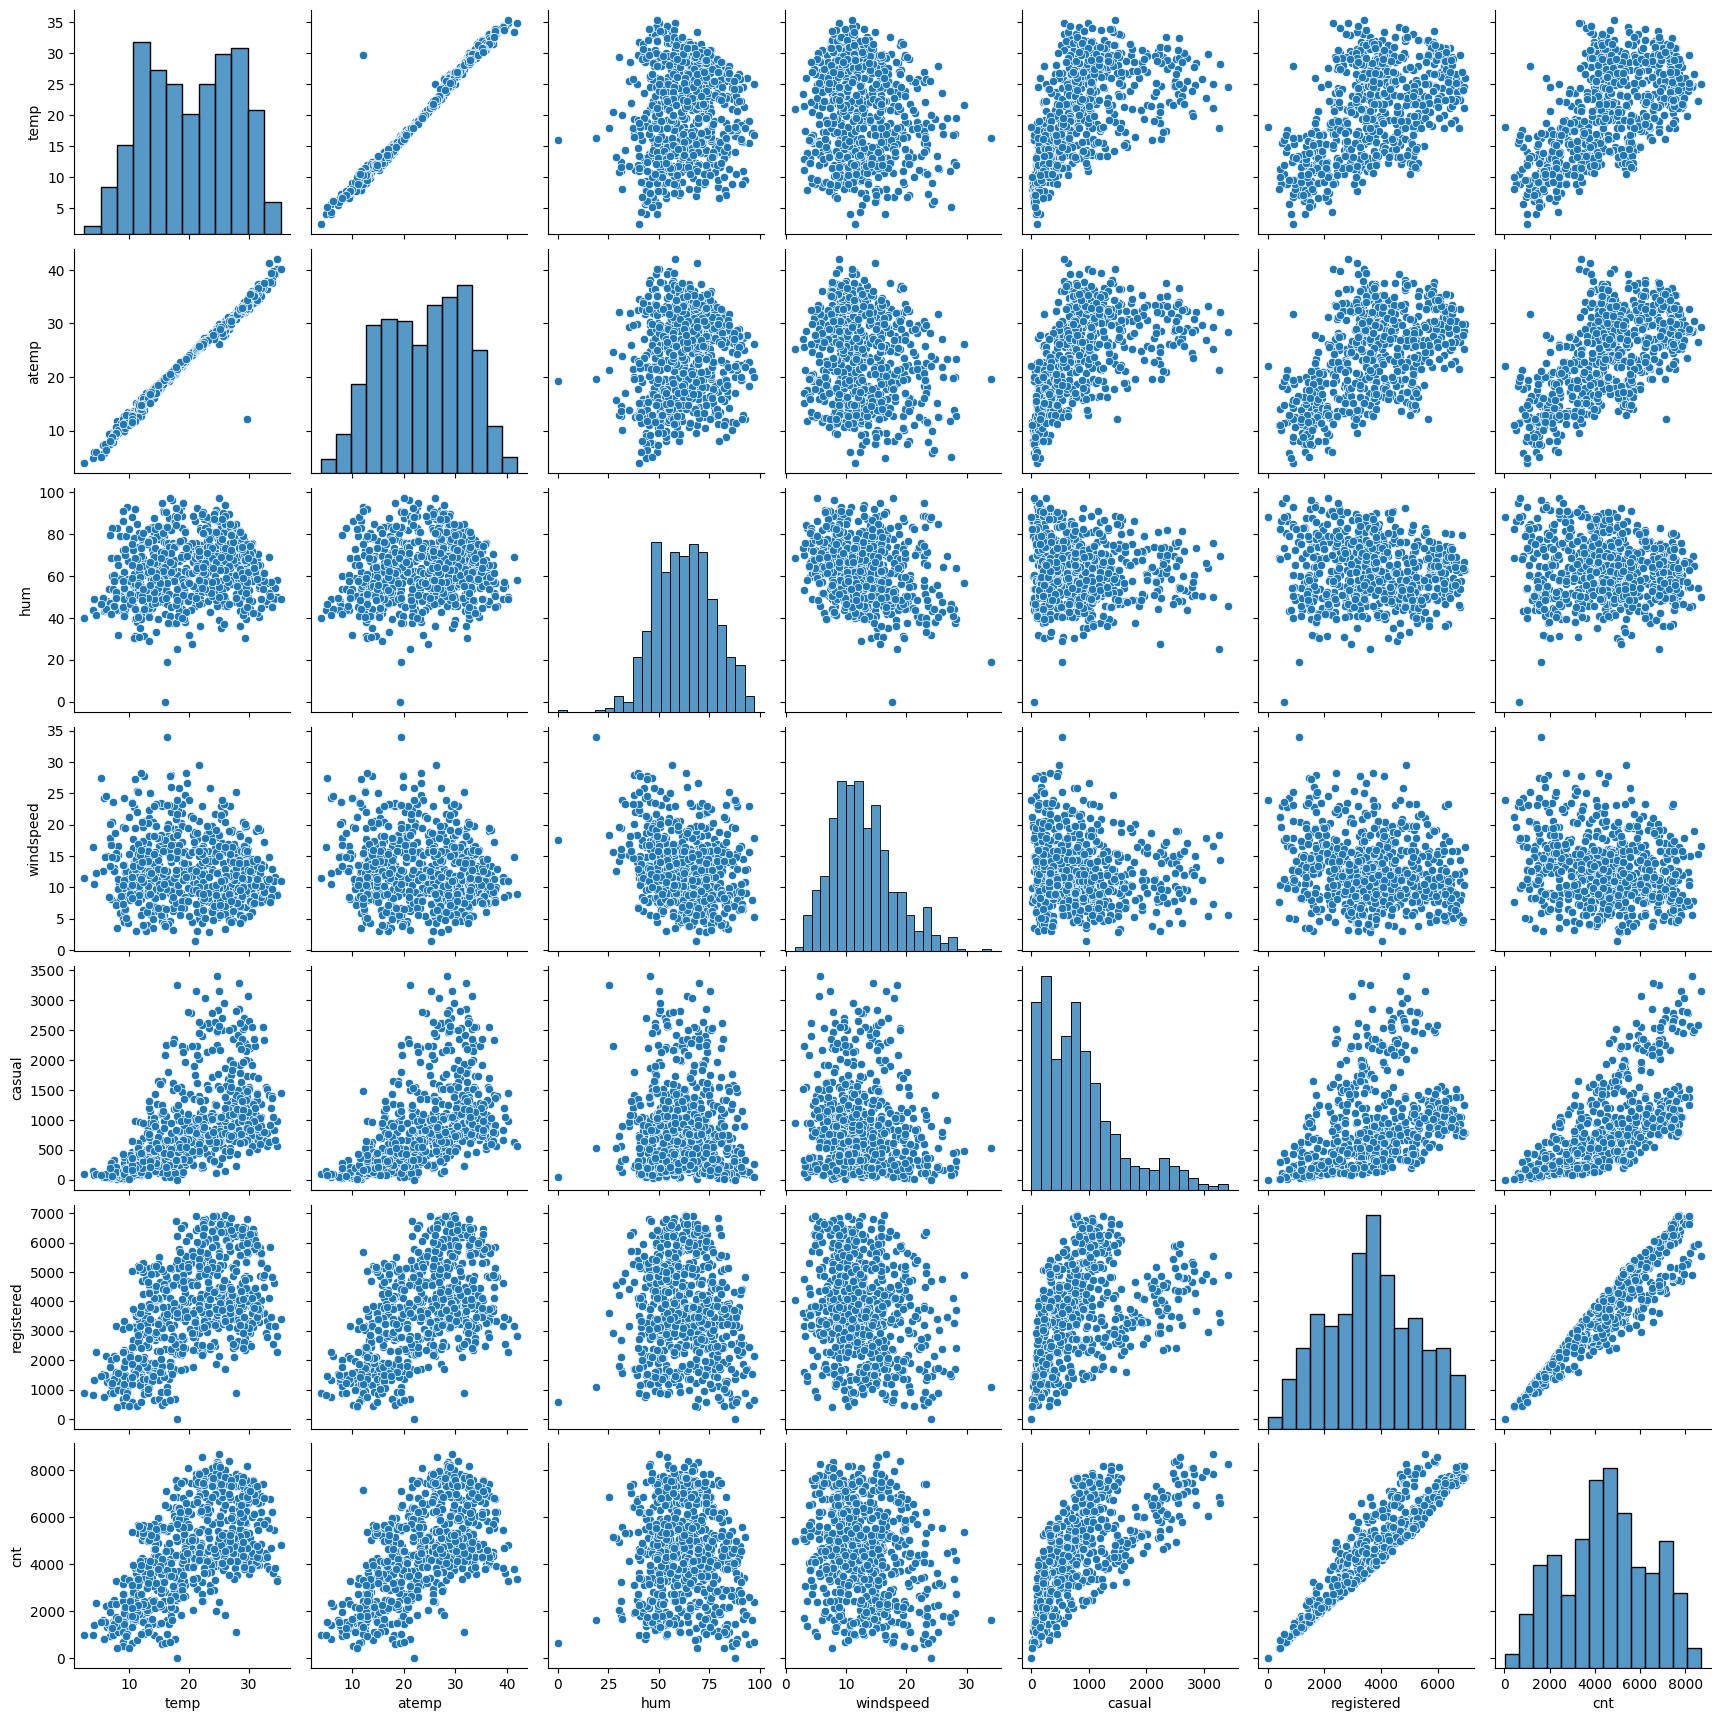

In [31]:
sns.pairplot(dataset_numeric)
plt.show()

In [32]:
cor = dataset_numeric.corr()
cor

,temp,atemp,hum,windspeed,casual,registered,cnt
temp,1.000000,0.991696,0.128565,-0.158186,0.542731,0.539436,0.627044
atemp,0.991696,1.000000,0.141512,-0.183876,0.543362,0.543678,0.630685
hum,0.128565,0.141512,1.000000,-0.248506,-0.075211,-0.089212,-0.098543
windspeed,-0.158186,-0.183876,-0.248506,1.000000,-0.167995,-0.217914,-0.235132
casual,0.542731,0.543362,-0.075211,-0.167995,1.000000,0.394137,0.672123
registered,0.539436,0.543678,-0.089212,-0.217914,0.394137,1.000000,0.945411
cnt,0.627044,0.630685,-0.098543,-0.235132,0.672123,0.945411,1.000000


<Axes: >

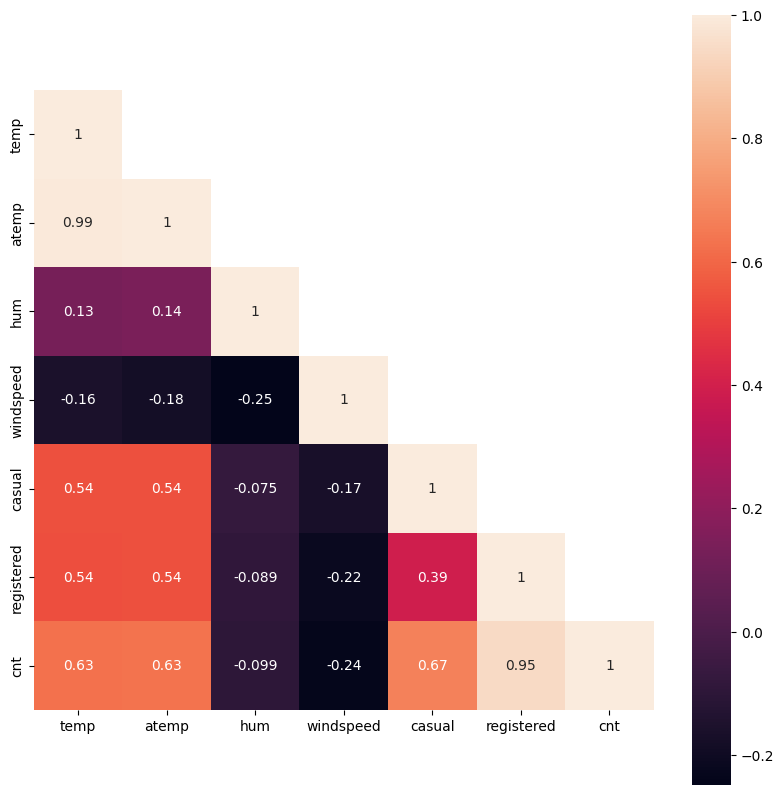

In [33]:
mask = np.array(cor)
mask[np.tril_indices_from(mask)] = False
fig,ax= plt.subplots()
fig.set_size_inches(10,10)
sns.heatmap(cor, mask=mask, vmax = 1, square = True, annot=True)


In [34]:
dataset.drop('atemp', axis=1, inplace=True)
dataset

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,hum,windspeed,casual,registered,cnt
0,1,01-01-2018,1,0,1,0,1,1,2,14.110847,80.5833,10.749882,331.0,654.0,985.0
1,2,02-01-2018,1,0,1,0,2,1,2,14.902598,69.6087,16.652113,131.0,670.0,801.0
2,3,03-01-2018,1,0,1,0,3,1,1,8.050924,43.7273,16.636703,120.0,1229.0,1349.0
3,4,04-01-2018,1,0,1,0,4,1,1,8.200000,59.0435,10.739832,108.0,1454.0,1562.0
4,5,05-01-2018,1,0,1,0,5,1,1,9.305237,43.6957,12.522300,82.0,1518.0,1600.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
725,726,27-12-2019,1,1,12,0,5,1,2,10.420847,65.2917,23.458911,247.0,1867.0,2114.0
726,727,28-12-2019,1,1,12,0,6,0,2,10.386653,59.0000,10.416557,644.0,2451.0,3095.0
727,728,29-12-2019,1,1,12,0,0,0,2,10.386653,75.2917,8.333661,159.0,1182.0,1341.0
728,729,30-12-2019,1,1,12,0,1,1,1,10.489153,48.3333,23.500518,364.0,1432.0,1796.0


                3. Data Preparation

In [35]:
dataset_categorical = dataset.select_dtypes(include=['object'])
dataset_categorical.head()

,dteday
0,01-01-2018
1,02-01-2018
2,03-01-2018
3,04-01-2018
4,05-01-2018


In [36]:
dataset_dummies = pd.get_dummies(dataset_categorical, drop_first=True)
dataset_dummies.head()

,dteday_01-01-2019,dteday_01-02-2018,dteday_01-02-2019,dteday_01-03-2018,dteday_01-03-2019,dteday_01-04-2018,dteday_01-04-2019,dteday_01-05-2018,dteday_01-05-2019,dteday_01-06-2018,...,dteday_31-05-2018,dteday_31-05-2019,dteday_31-07-2018,dteday_31-07-2019,dteday_31-08-2018,dteday_31-08-2019,dteday_31-10-2018,dteday_31-10-2019,dteday_31-12-2018,dteday_31-12-2019
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [37]:
dataset = dataset.drop(list(dataset_categorical.columns), axis=1)
dataset

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,hum,windspeed,casual,registered,cnt
0,1,1,0,1,0,1,1,2,14.110847,80.5833,10.749882,331.0,654.0,985.0
1,2,1,0,1,0,2,1,2,14.902598,69.6087,16.652113,131.0,670.0,801.0
2,3,1,0,1,0,3,1,1,8.050924,43.7273,16.636703,120.0,1229.0,1349.0
3,4,1,0,1,0,4,1,1,8.200000,59.0435,10.739832,108.0,1454.0,1562.0
4,5,1,0,1,0,5,1,1,9.305237,43.6957,12.522300,82.0,1518.0,1600.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
725,726,1,1,12,0,5,1,2,10.420847,65.2917,23.458911,247.0,1867.0,2114.0
726,727,1,1,12,0,6,0,2,10.386653,59.0000,10.416557,644.0,2451.0,3095.0
727,728,1,1,12,0,0,0,2,10.386653,75.2917,8.333661,159.0,1182.0,1341.0
728,729,1,1,12,0,1,1,1,10.489153,48.3333,23.500518,364.0,1432.0,1796.0


In [38]:
dataset = pd.concat([dataset, dataset_dummies], axis=1)
dataset

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,hum,...,dteday_31-05-2018,dteday_31-05-2019,dteday_31-07-2018,dteday_31-07-2019,dteday_31-08-2018,dteday_31-08-2019,dteday_31-10-2018,dteday_31-10-2019,dteday_31-12-2018,dteday_31-12-2019
0,1,1,0,1,0,1,1,2,14.110847,80.5833,...,False,False,False,False,False,False,False,False,False,False
1,2,1,0,1,0,2,1,2,14.902598,69.6087,...,False,False,False,False,False,False,False,False,False,False
2,3,1,0,1,0,3,1,1,8.050924,43.7273,...,False,False,False,False,False,False,False,False,False,False
3,4,1,0,1,0,4,1,1,8.200000,59.0435,...,False,False,False,False,False,False,False,False,False,False
4,5,1,0,1,0,5,1,1,9.305237,43.6957,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
725,726,1,1,12,0,5,1,2,10.420847,65.2917,...,False,False,False,False,False,False,False,False,False,False
726,727,1,1,12,0,6,0,2,10.386653,59.0000,...,False,False,False,False,False,False,False,False,False,False
727,728,1,1,12,0,0,0,2,10.386653,75.2917,...,False,False,False,False,False,False,False,False,False,False
728,729,1,1,12,0,1,1,1,10.489153,48.3333,...,False,False,False,False,False,False,False,False,False,False


In [43]:
dataset = dataset.drop(['instant'], axis=1 , inplace=False)
dataset.head()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,hum,windspeed,...,dteday_31-05-2018,dteday_31-05-2019,dteday_31-07-2018,dteday_31-07-2019,dteday_31-08-2018,dteday_31-08-2019,dteday_31-10-2018,dteday_31-10-2019,dteday_31-12-2018,dteday_31-12-2019
0,1,0,1,0,1,1,2,14.110847,80.5833,10.749882,...,False,False,False,False,False,False,False,False,False,False
1,1,0,1,0,2,1,2,14.902598,69.6087,16.652113,...,False,False,False,False,False,False,False,False,False,False
2,1,0,1,0,3,1,1,8.050924,43.7273,16.636703,...,False,False,False,False,False,False,False,False,False,False
3,1,0,1,0,4,1,1,8.200000,59.0435,10.739832,...,False,False,False,False,False,False,False,False,False,False
4,1,0,1,0,5,1,1,9.305237,43.6957,12.522300,...,False,False,False,False,False,False,False,False,False,False


###        4. Model Building and Evaluation

In [45]:
from sklearn import linear_model
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
np.random.seed(0)
df_train, df_test = train_test_split(dataset, train_size=0.7, test_size=0.3, random_state=100)
df_train

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,hum,windspeed,...,dteday_31-05-2018,dteday_31-05-2019,dteday_31-07-2018,dteday_31-07-2019,dteday_31-08-2018,dteday_31-08-2019,dteday_31-10-2018,dteday_31-10-2019,dteday_31-12-2018,dteday_31-12-2019
653,4,1,10,0,3,1,1,19.201653,55.8333,12.208807,...,False,False,False,False,False,False,False,False,False,False
576,3,1,7,0,3,1,1,29.246653,70.4167,11.083475,...,False,False,False,True,False,False,False,False,False,False
426,1,1,3,0,0,0,2,16.980847,62.1250,10.792293,...,False,False,False,False,False,False,False,False,False,False
728,1,1,12,0,1,1,1,10.489153,48.3333,23.500518,...,False,False,False,False,False,False,False,False,False,False
482,2,1,4,0,0,0,2,15.443347,48.9583,8.708325,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
526,2,1,6,0,2,1,2,29.554153,58.7917,13.916771,...,False,False,False,False,False,False,False,False,False,False
578,3,1,8,0,5,1,1,30.852500,65.9583,8.666718,...,False,False,False,False,False,False,False,False,False,False
53,1,0,2,0,5,1,1,9.091299,42.3043,6.305571,...,False,False,False,False,False,False,False,False,False,False
350,4,0,12,0,1,1,2,10.591653,56.0833,16.292189,...,False,False,False,False,False,False,False,False,False,False


In [47]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
var = ["temp", "hum", "windspeed", "casual", "registered", "cnt"]
df_train[var] = scaler.fit_transform(df_train[var])
df_train.describe()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,hum,windspeed,casual,registered,cnt
count,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000
mean,2.517647,0.507843,6.549020,0.025490,2.950980,0.711765,1.401961,0.537262,0.650369,0.320768,0.254661,0.523944,0.513620
std,1.111947,0.500429,3.468714,0.157763,1.977166,0.453386,0.547540,0.225844,0.145882,0.169797,0.206011,0.228175,0.224593
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,3.000000,0.000000,1.000000,0.000000,1.000000,0.339853,0.538643,0.199179,0.094179,0.353487,0.356420
50%,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.540519,0.653714,0.296763,0.212740,0.525123,0.518638
75%,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.735215,0.754830,0.414447,0.327415,0.696073,0.684710
max,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x7ba42a6dfd80> (for post_execute):


KeyboardInterrupt: 

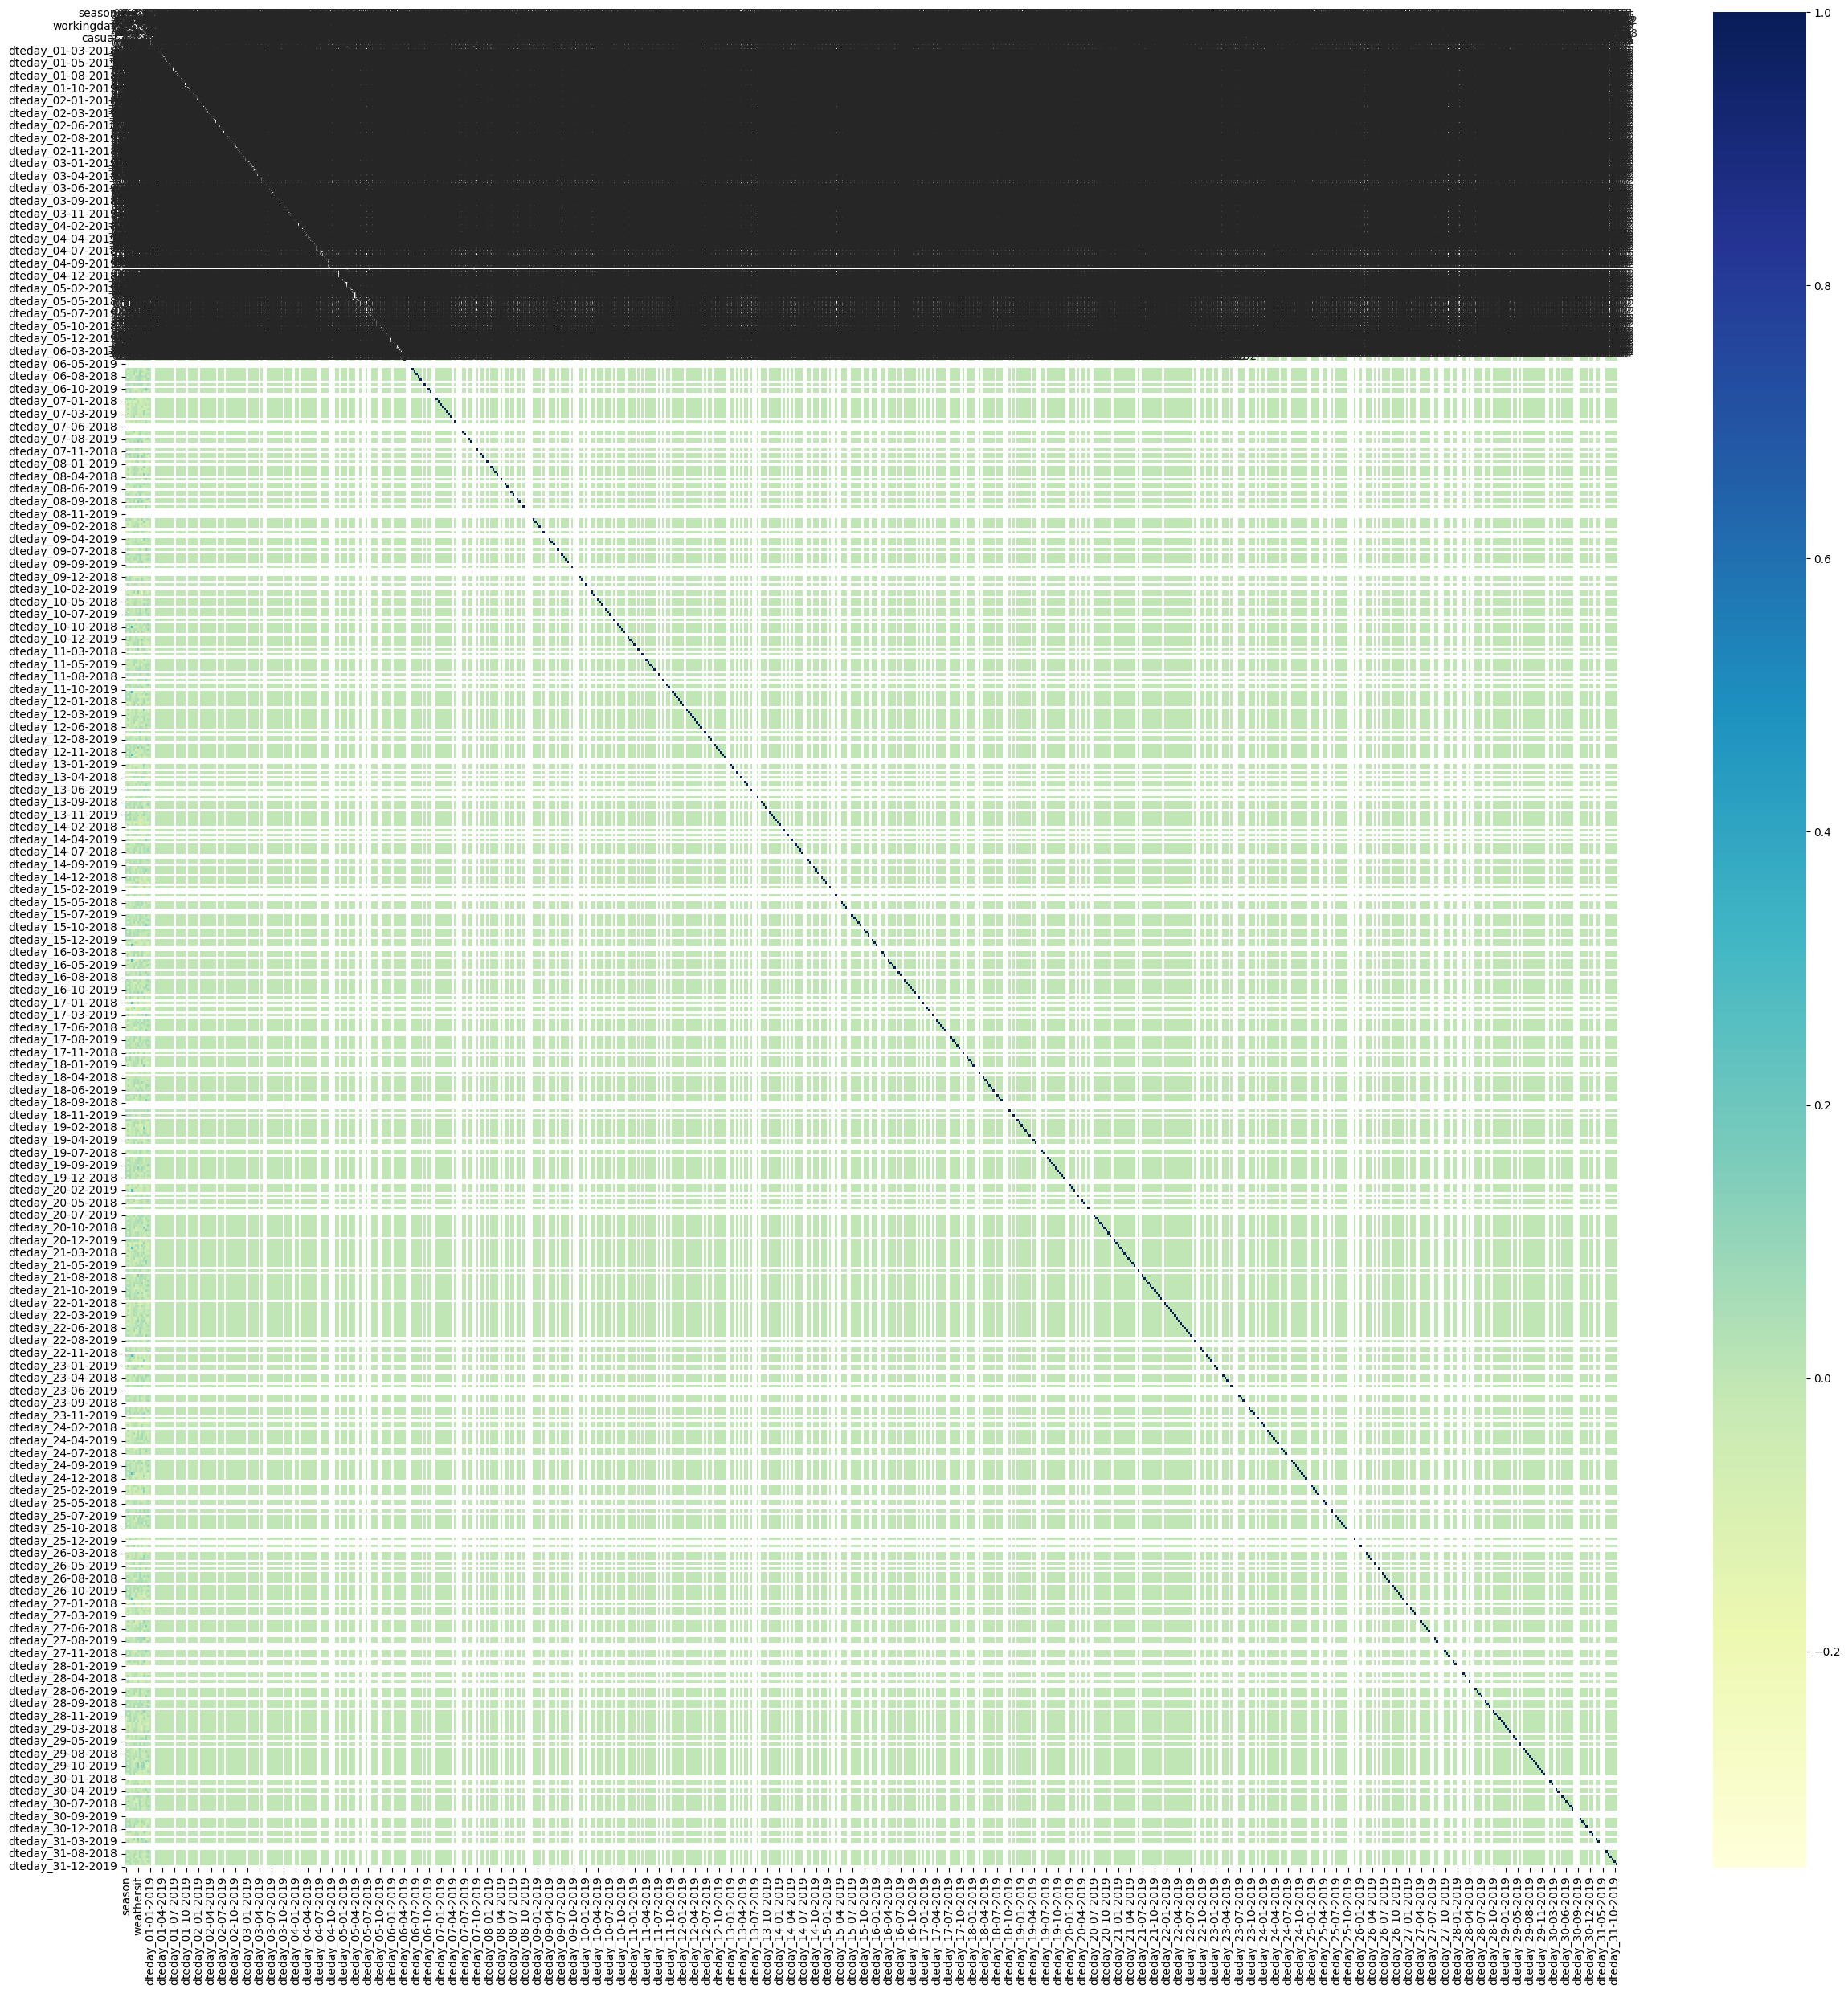

In [53]:
plt.figure(figsize= (30,30))
sns.heatmap(df_train.corr(), annot=True, cmap="YlGnBu")
plt.show()

In [52]:
y_train = df_train.pop('cnt')
x_train = df_train.drop(["casual", "registered"], axis=1)
x_train.head()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,hum,windspeed,...,dteday_31-05-2018,dteday_31-05-2019,dteday_31-07-2018,dteday_31-07-2019,dteday_31-08-2018,dteday_31-08-2019,dteday_31-10-2018,dteday_31-10-2019,dteday_31-12-2018,dteday_31-12-2019
653,4,1,10,0,3,1,1,0.509887,0.575354,0.300794,...,False,False,False,False,False,False,False,False,False,False
576,3,1,7,0,3,1,1,0.815169,0.725633,0.264686,...,False,False,False,True,False,False,False,False,False,False
426,1,1,3,0,0,0,2,0.442393,0.640189,0.255342,...,False,False,False,False,False,False,False,False,False,False
728,1,1,12,0,1,1,1,0.245101,0.498067,0.663106,...,False,False,False,False,False,False,False,False,False,False
482,2,1,4,0,0,0,2,0.395666,0.504508,0.188475,...,False,False,False,False,False,False,False,False,False,False


In [54]:
np.asarray(df_train)

array([[4, 1, 10, ..., False, False, False],
       [3, 1, 7, ..., False, False, False],
       [1, 1, 3, ..., False, False, False],
       ...,
       [1, 0, 2, ..., False, False, False],
       [4, 0, 12, ..., False, False, False],
       [2, 0, 3, ..., False, False, False]], dtype=object)

In [ ]:
import statsmodels.api as sm
x_train_lm = sm.add_constant(x_train)
lr = sm.OLS(y_train, x_train_lm).fit()

In [57]:
x_train_lm

,const,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,hum,...,dteday_31-05-2018,dteday_31-05-2019,dteday_31-07-2018,dteday_31-07-2019,dteday_31-08-2018,dteday_31-08-2019,dteday_31-10-2018,dteday_31-10-2019,dteday_31-12-2018,dteday_31-12-2019
653,1.0,4,1,10,0,3,1,1,0.509887,0.575354,...,False,False,False,False,False,False,False,False,False,False
576,1.0,3,1,7,0,3,1,1,0.815169,0.725633,...,False,False,False,True,False,False,False,False,False,False
426,1.0,1,1,3,0,0,0,2,0.442393,0.640189,...,False,False,False,False,False,False,False,False,False,False
728,1.0,1,1,12,0,1,1,1,0.245101,0.498067,...,False,False,False,False,False,False,False,False,False,False
482,1.0,2,1,4,0,0,0,2,0.395666,0.504508,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
526,1.0,2,1,6,0,2,1,2,0.824514,0.605840,...,False,False,False,False,False,False,False,False,False,False
578,1.0,3,1,8,0,5,1,1,0.863973,0.679690,...,False,False,False,False,False,False,False,False,False,False
53,1.0,1,0,2,0,5,1,1,0.202618,0.435939,...,False,False,False,False,False,False,False,False,False,False
350,1.0,4,0,12,0,1,1,2,0.248216,0.577930,...,False,False,False,False,False,False,False,False,False,False


In [62]:
lm = LinearRegression()
lm.fit(x_train, y_train)

LinearRegression()

In [ ]:
print(lm.coef_)
print(lm.intercept_)
[0.23242979 -0.1371431 -0.06364531 -0.0813371 0.4412489 -0.14727961
 -0.19178201 -0.3803283 0.0469272 0.11455192 0.02862498 -0.04633998
 -0.0395765 -0.06165778 -0.03457406 0.00230692 -0.000147585 -0.02794094
 0.00873312 -0.00793766]

In [ ]:
lr.summary()

In [ ]:
from sklearn.feature_selection import RFE
lm = LinearRegression()
rfe1 = RFE(lm, 15)
rfe1.fit(x_train, y_train)
print(rfel.support_)
print(rfel.ranking_)

[ True  True False True True True True True False True False True
  True True True False False True True False False False False False False ]
  [ 1 1 2 1 1 1 1 1 5 1 6 1 1 1 1 11 13 1 1 12 1 7 3 4 9 8 10]

In [ ]:
col1 = x_train.columns[rfel1.support_]
col1

In [71]:
x_train_rfe1 = x_train['dteday_01-01-2019']

x_train_rfel1 = sm.add_constant(x_train_rfe1)
lr = sm.OLS(y_train, x_train_rfe1).fit()
lr.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                    cnt   R-squared (uncentered):                   0.000
Model:                            OLS   Adj. R-squared (uncentered):             -0.002
Method:                 Least Squares   F-statistic:                             0.2172
Date:                Fri, 27 Jun 2025   Prob (F-statistic):                       0.641
Time:                        08:11:10   Log-Likelihood:                         -428.29
No. Observations:                 510   AIC:                                      858.6
Df Residuals:                     509   BIC:                                      862.8
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
dteday_01-01-2019     0.2614      0.561      0.466      0.641      -0.841       1.363
==============================================================================
Omnibus:                       46.419   Durbin-Watson:                   0.303
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               15.119
Skew:                          -0.069   Prob(JB):                     0.000521
Kurtosis:                       2.168   Cond. No.                         1.00
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [ ]:
from statsmodels.stats.outliers_influence import varaince_inflaction_factor

a = x_train_rfel1.drop('const', axis=1)
vif = pd.DataFrame()
vif['fearures'] = a.columns
vif['VIF'] = [variance_inflation_factor(a.values, i) for i in range(a.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif

In [ ]:
lm = linearRegression()
rfe2 = RFE(lm, 7)

rfe2.fit(x_train, y_train)
print(rfe2.support_)
print(rfe2.ranking_)

In [ ]:
col2 = x_train.columns[rfe2.support_]

x_train_rfe2 = x_train[col2]

x_train_rfe2 = sm.add_constant(x_train_rfe2)
lm2 = sm.OLS(y_train, x_train_rfe2).fit()
lm2.summary()

In [ ]:
b = x_train_rfe2.drop('const', axis=1)
vifl = pd.DataFrame()
vifl['VIF'] = [variance_inflation_factor(b.values, i) for i in range(b.shape[1])]
vifl['features'] = b.columns
vifl['VIF'] = round(vifl['VIF'], 2)
vifl.sort_values('VIF Factor', ascending=False)

In [ ]:
y_train_cnt = lm2.predict(x_train_rfe2)

<Axes: xlabel='cnt', ylabel='Density'>

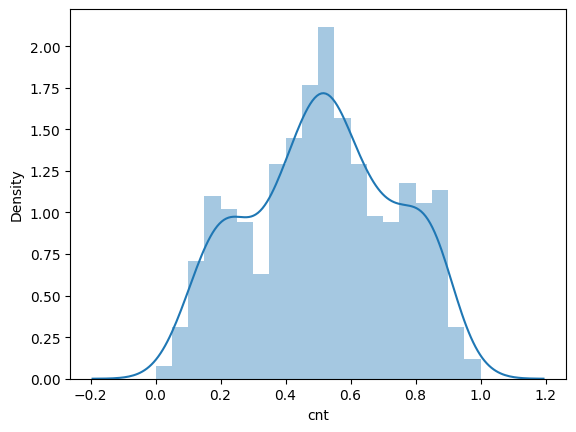

In [92]:
fig = plt.figure()
sns.distplot((y_train), bins=20)

In [93]:
df_test[var] = scaler.transform(df_test[var])
df_test.describe()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,hum,windspeed,casual,registered,cnt
count,219.000000,219.000000,219.000000,219.000000,219.000000,219.000000,219.000000,219.000000,219.000000,219.000000,219.000000,219.000000,219.000000
mean,2.456621,0.479452,6.474886,0.036530,3.100457,0.639269,1.374429,20.815737,61.961883,12.600130,875.968037,3671.013699,4546.981735
std,1.109463,0.500722,3.421875,0.188034,2.058536,0.481313,0.538843,7.689600,14.456669,4.984858,712.783588,1509.322560,1898.633630
min,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,3.957390,25.416700,1.500244,9.000000,432.000000,441.000000
25%,1.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,14.093750,51.166700,9.021282,336.500000,2507.500000,3303.500000
50%,2.000000,0.000000,6.000000,0.000000,3.000000,1.000000,1.000000,20.807500,60.916700,12.167200,736.000000,3667.000000,4579.000000
75%,3.000000,1.000000,9.000000,0.000000,5.000000,1.000000,2.000000,27.401653,72.192050,15.395629,1190.000000,4624.000000,5869.500000
max,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,34.815847,97.250000,27.999836,3410.000000,6844.000000,8395.000000


In [94]:
y_test = df_test.pop('cnt')
x_test = df_test.drop(["casual", "registered"], axis=1)

x_test.head()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,hum,windspeed,...,dteday_31-05-2018,dteday_31-05-2019,dteday_31-07-2018,dteday_31-07-2019,dteday_31-08-2018,dteday_31-08-2019,dteday_31-10-2018,dteday_31-10-2019,dteday_31-12-2018,dteday_31-12-2019
184,3,0,7,1,3,0,2,29.793347,63.7917,5.459106,...,False,False,False,False,False,False,False,False,False,False
535,2,1,6,0,4,1,1,32.082500,59.2083,7.625404,...,False,False,False,False,False,False,False,False,False,False
299,4,0,10,0,6,0,2,19.270000,81.2917,13.250121,...,False,False,False,False,False,False,False,False,False,False
221,3,0,8,0,5,1,1,31.433347,42.4167,13.417286,...,False,False,False,False,False,False,False,False,False,False
152,2,0,6,0,6,0,1,29.315000,30.5000,19.583229,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
c = x_train_rfe2.drop('const', axis=1)


In [ ]:
col2 = c.columns
x_test_rfe2 = x_test[col2]
x_test_rfe2 = sm.add_constant(x_test_rfe2)
x_test_rfe2.info()

In [ ]:
y_pred = lm2.predict(x_test_rfe2)

plt.figure()
plt.scatter(y_test, y_pred)

In [ ]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

In [ ]:
plt.figure(figsize=(8,5))

sns.heatmap(dataset[col2].corr(), cmap = "YlGnBu", annot=True)
plt.show()

<Axes: xlabel='cnt', ylabel='Density'>

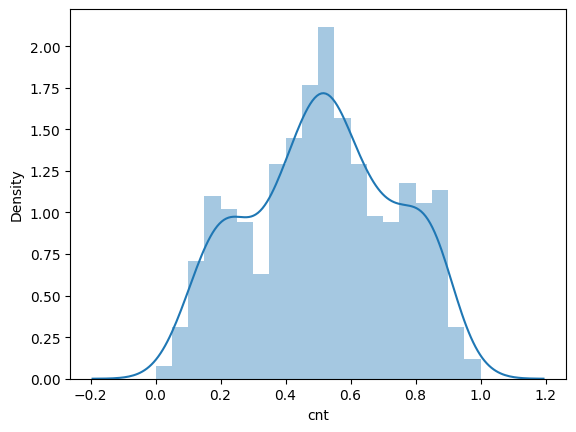

In [110]:
fig = plt.figure()
sns.distplot((y_train), bins=20)